# Example of calling PRIMAT from within python, so as to produce Schramm's diagrams

In [1]:
import subprocess
import os
import numpy as np
import csv
import matplotlib.pyplot as plt

# Set rcParams for LaTeX rendering
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "lines.linewidth": 0.8,
    "figure.figsize": (6.8,5.2),
    #"xtick.labelsize": 8,
    #"ytick.labelsize": 8,
    #"axes.labelsize": 9,
    "ytick.right": True,
    "xtick.top": True,
    "ytick.direction": "in",
    "xtick.direction": "in",
})

currentdirectory = os.getcwd()
print(currentdirectory)

MathKernelCommand = '/Applications/Wolfram.app/Contents/MacOS/MathKernel'#Modify to match the location of Mathematcia Kernel

/Users/pitrou/Dropbox/iap/notebooks/PRIMAT2024/PythonInterface


### Tools to prepare arguments which will be sent to Mathematica, and for calling PRIMAt inside Mathematica

In [2]:
#This function converts a number in python/fortran format into a string that Mathematica can understand and convert to a number in Mathematica format
def stringfromnumeric(number):
    if isinstance(number,float):
        return "Interpreter[\"Number\"][StringDelete[\""+str(number)+"\",\" \"]]"
    else:
        return number

In [3]:
def RunPRIMAT(DictArgs, filem, desiredoutput, MathKernelCommand):
    #This dictionary is packaged into a string which will be used as an argument to the Mathematica Kernel
    stringitems = [f"{key}={stringfromnumeric(value)}" for key, value in DictArgs.items()]

    ExtraArgumentsString = "; ".join(stringitems)+";"
    print(ExtraArgumentsString)
    
    #Outputfile is set to the desired output for Mathematica (as a string argument)
    optionoutput = "$Outputfile=\""+desiredoutput+"\""
    
    #Then we call the Mathematica script
    #We have two arguments to the Mathemtiaca script
    # 1) the ExtraArgumentsString which is a list of variables to update wrt the default ones before running the solver
    # 2) The name of the output file in which the script write a dictionary of the results
    return subprocess.call([MathKernelCommand,"-initfile",filem,ExtraArgumentsString,optionoutput])

## Computes abundances on a grid of $\eta$ values (baryon to photon ratio), and computes error with a Monte Carlo on nuclear rates

In [4]:
fileeta = 'PyPRIMAT-MonteCarlo.m' #Input file which will load PRIMAT and dump the results in a csv file
desiredoutput = currentdirectory+"/Yi_MC.csv" #Name of the csv file used for output

In [5]:
# Generate the range of eta values
leta_values = np.linspace(-10, -9, 20)
eta_values = np.array([10**leta for leta in leta_values])
eta_values

array([1.00000000e-10, 1.12883789e-10, 1.27427499e-10, 1.43844989e-10,
       1.62377674e-10, 1.83298071e-10, 2.06913808e-10, 2.33572147e-10,
       2.63665090e-10, 2.97635144e-10, 3.35981829e-10, 3.79269019e-10,
       4.28133240e-10, 4.83293024e-10, 5.45559478e-10, 6.15848211e-10,
       6.95192796e-10, 7.84759970e-10, 8.85866790e-10, 1.00000000e-09])

In [6]:
def ComputeMCEtaGrid(eta_values, NumMCPoints):
    results = []
    for eta in eta_values:
        dictarg= {"Eta":eta,"LengthMC":NumMCPoints,"$ReducedNetwork":True,"$ParallelBool":True,"$Verbose":False}
        RunPRIMAT(dictarg,fileeta,desiredoutput,MathKernelCommand)
        resonMC = np.loadtxt(desiredoutput,delimiter=',')
        print('python read results are', resonMC)
        result_2d = resonMC
        results.append(result_2d)
    result_3d = np.array(results)
    return result_3d

In [7]:
NumMCPoints=20
results=ComputeMCEtaGrid(eta_values,NumMCPoints)

Eta=Interpreter["Number"][StringDelete["1e-10"," "]]; LengthMC=20; $ReducedNetwork=True; $ParallelBool=True; $Verbose=False;
Wolfram 14.1.0 Kernel for Mac OS X ARM (64-bit)
Copyright 1988-2024 Wolfram Research, Inc.
For info the outputfile is /Users/pitrou/Dropbox/iap/notebooks/PRIMAT2024/Pyt\
 
>    honInterface/Yi_MC.csv
            -10
Eta is 1. 10
LengthMC is 20
                      7
Ωbh2Overη 3.65299 10
Running a Monte-Carlo with 20 points.
Number of Kernels 4
(kernel 2):
Iteration 4  Memory usage = 72553880 time = 1.36046  Kernel : 2

(kernel 3):
Iteration 7  Memory usage = 72555288 time = 1.36008  Kernel : 3

(kernel 4):
Iteration 10  Memory usage = 72870776 time = 1.35941  Kernel : 4

(kernel 1):
Iteration 1  Memory usage = 72878216 time = 1.36287  Kernel : 1

(kernel 1):
Iteration 2  Memory usage = 73510424 time = 1.19971  Kernel : 1

(kernel 3):
Iteration 8  Memory usage = 73206712 time = 1.21675  Kernel : 3

(kernel 4):
Iteration 11  Memory usage = 73513264 time = 1.21833 

### Results and plots

In [8]:
YPobs=0.2453
sigYPobs=0.0034

DHobs=2.527e-5
sigDHobs=0.030e-5

He3obsmin=0.9e-5
He3obsmax=1.3e-5

Li7obs=1.58e-10
sigLi7obs=0.3e-10

h2OmegaOverEta = 3.6529876e7
Meanh2Omega =   0.022425
sigh2Omega = 0.000136

etamin= (Meanh2Omega-sigh2Omega)/h2OmegaOverEta
etamax= (Meanh2Omega+sigh2Omega)/h2OmegaOverEta

In [9]:
YPvalues = results[:,0]
DHvalues = results[:,1]
He3values = results[:,2]
Li7values = results[:,3]

def calculate_means_and_stds(list_of_lists):
    means = np.array([np.mean(sublist) for sublist in list_of_lists])
    stds = np.array([np.std(sublist) for sublist in list_of_lists])
    return means, stds

YPmeans, YPsigmas = calculate_means_and_stds(YPvalues)
DHmeans, DHsigmas = calculate_means_and_stds(DHvalues)
He3means, He3sigmas = calculate_means_and_stds(He3values)
Li7means, Li7sigmas = calculate_means_and_stds(Li7values)

#YPmeans, YPsigmas

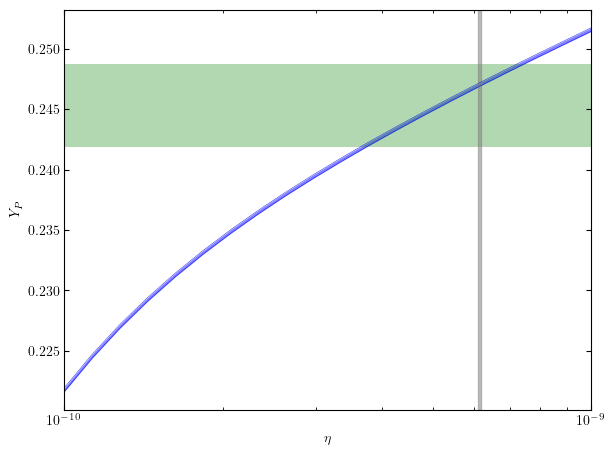

In [10]:
plt.plot(eta_values,YPmeans+YPsigmas,color='blue',linewidth=0.3)
plt.plot(eta_values,YPmeans-YPsigmas,color='blue',linewidth=0.3)
plt.fill_between(eta_values, YPmeans-YPsigmas, YPmeans+YPsigmas, color='blue', alpha=0.5,linewidth=0.001)

plt.fill_between(eta_values, YPobs-sigYPobs, YPobs+sigYPobs, color='green', alpha=0.3,linewidth=0.001)
plt.axvspan(etamin, etamax, color='gray', alpha=0.5)



plt.xlabel(r'$\eta$')
plt.xlim(1e-10,1e-9)
plt.xscale('log')
plt.ylabel(r'$Y_P$')

# Adding a legend
#plt.legend()

# Display the plot
plt.show()

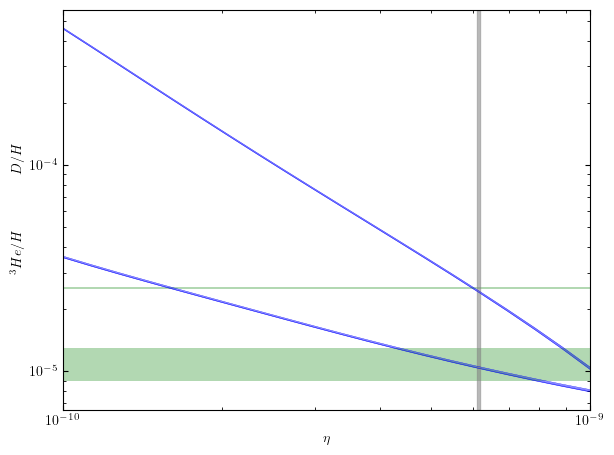

In [11]:
plt.plot(eta_values,DHmeans+DHsigmas,color='blue',linewidth=0.3)
plt.plot(eta_values,DHmeans-DHsigmas,color='blue',linewidth=0.3)
plt.fill_between(eta_values, DHmeans-DHsigmas, DHmeans+DHsigmas, color='blue', alpha=0.5,linewidth=0.001)

plt.fill_between(eta_values, DHobs-sigDHobs, DHobs+sigDHobs, color='green', alpha=0.3,linewidth=0.001)


plt.plot(eta_values,He3means+He3sigmas,color='blue',linewidth=0.3)
plt.plot(eta_values,He3means-He3sigmas,color='blue',linewidth=0.3)
plt.fill_between(eta_values, He3means-He3sigmas, He3means+He3sigmas, color='blue', alpha=0.5,linewidth=0.001)
plt.fill_between(eta_values, He3obsmin, He3obsmax, color='green', alpha=0.3,linewidth=0.001)

plt.axvspan(etamin, etamax, color='gray', alpha=0.5)

plt.xlabel(r'$\eta$')
plt.xlim(1e-10,1e-9)
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'${}^3He/H \qquad \qquad D/H$')

# Adding a legend
#plt.legend()

# Display the plot
plt.show()

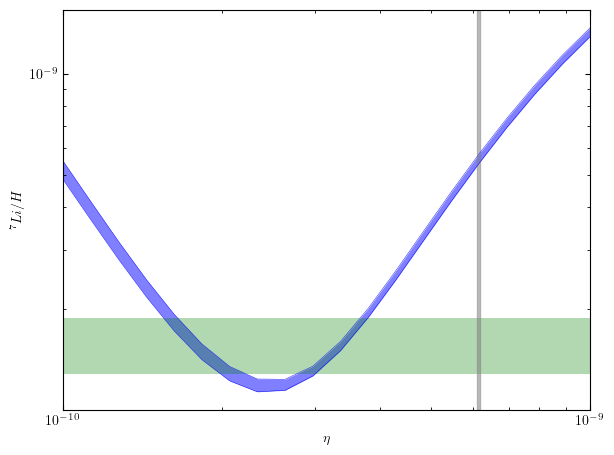

In [12]:
plt.plot(eta_values,Li7means+Li7sigmas,color='blue',linewidth=0.3)
plt.plot(eta_values,Li7means-Li7sigmas,color='blue',linewidth=0.3)
plt.fill_between(eta_values, Li7means-Li7sigmas, Li7means+Li7sigmas, color='blue', alpha=0.5,linewidth=0.001)
plt.fill_between(eta_values, Li7obs-sigLi7obs, Li7obs+sigLi7obs, color='green', alpha=0.3,linewidth=0.001)

plt.axvspan(etamin, etamax, color='gray', alpha=0.5)

plt.xlabel(r'$\eta$')
plt.xlim(1e-10,1e-9)
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'${}^7 Li/H$')

# Adding a legend
#plt.legend()

# Display the plot
plt.show()